Running experiment 1: Polynomial Regression

SGD             | Loss: 0.00999
SGD (Polyak)    | Loss: 0.00999
SGD (Nesterov)  | Loss: 0.00999
Adam            | Loss: 0.01340
L-BFGS          | Loss: 0.00999


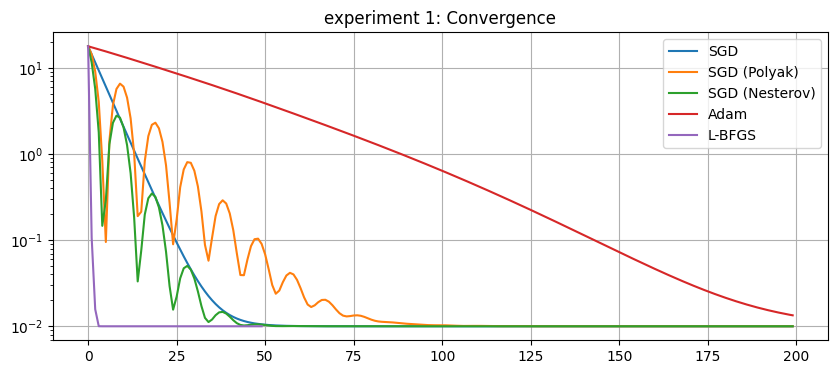

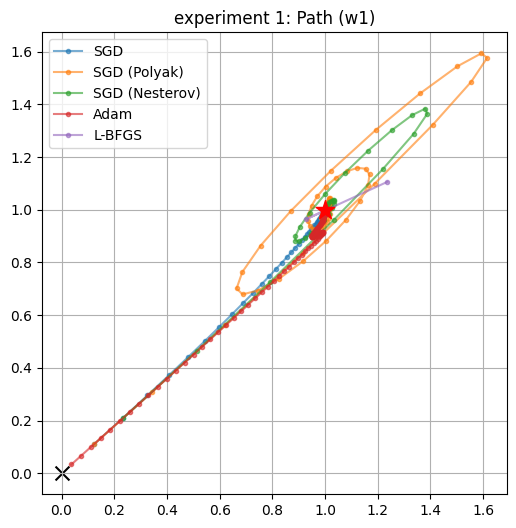


Running Non-Convex Classification (Spiral)

Optimizer       | Activation | Best LR  | Acc %  | Time
-----------------------------------------------------------------
SGD             | CReLU      | 0.1      | 69.2000  | 7.81s
SGD             | zReLU      | 0.5      | 60.0000  | 4.45s
SGD             | modReLU    | 0.01     | 86.2000  | 10.23s
SGD             | Cardioid   | 0.01     | 66.0000  | 24.75s
SGD (Polyak)    | CReLU      | 0.01     | 61.0000  | 5.95s
SGD (Polyak)    | zReLU      | 0.1      | 72.4000  | 6.58s
SGD (Polyak)    | modReLU    | 0.01     | 99.1000  | 9.31s
SGD (Polyak)    | Cardioid   | 0.01     | 63.6000  | 23.11s
SGD (Nesterov)  | CReLU      | 0.01     | 61.5000  | 7.34s
SGD (Nesterov)  | zReLU      | 0.1      | 70.7000  | 5.17s
SGD (Nesterov)  | modReLU    | 0.01     | 100.0000  | 8.86s
SGD (Nesterov)  | Cardioid   | 0.01     | 64.0000  | 24.69s
Adam            | CReLU      | 0.01     | 63.7000  | 8.23s
Adam            | zReLU      | 0.1      | 64.1000  | 4.36s
Ad

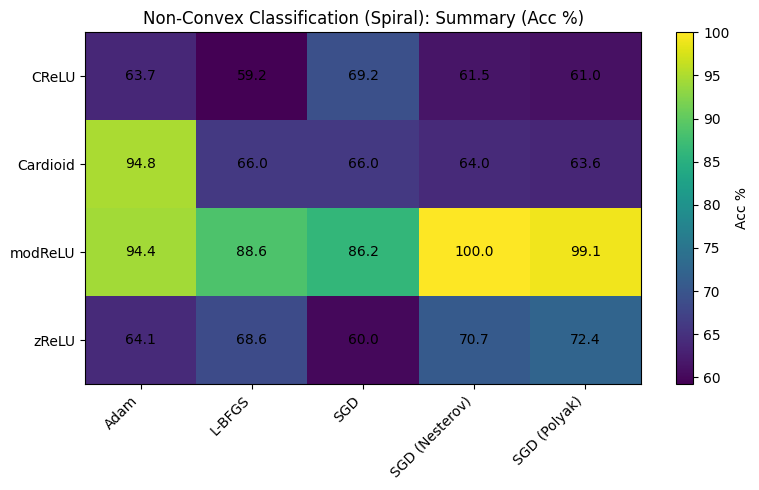

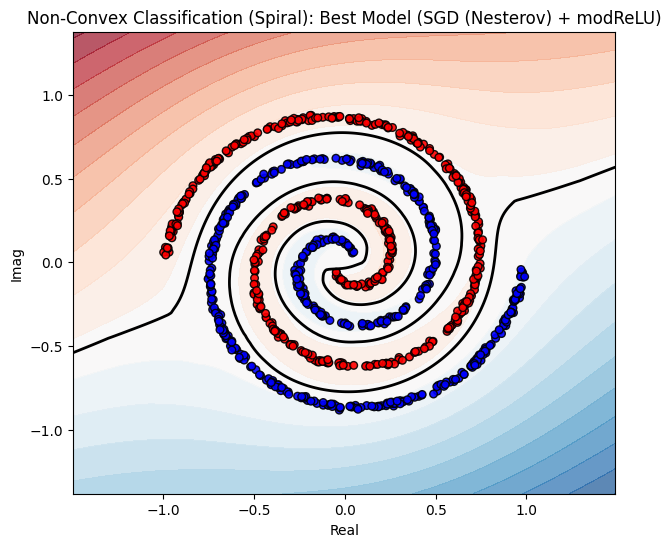

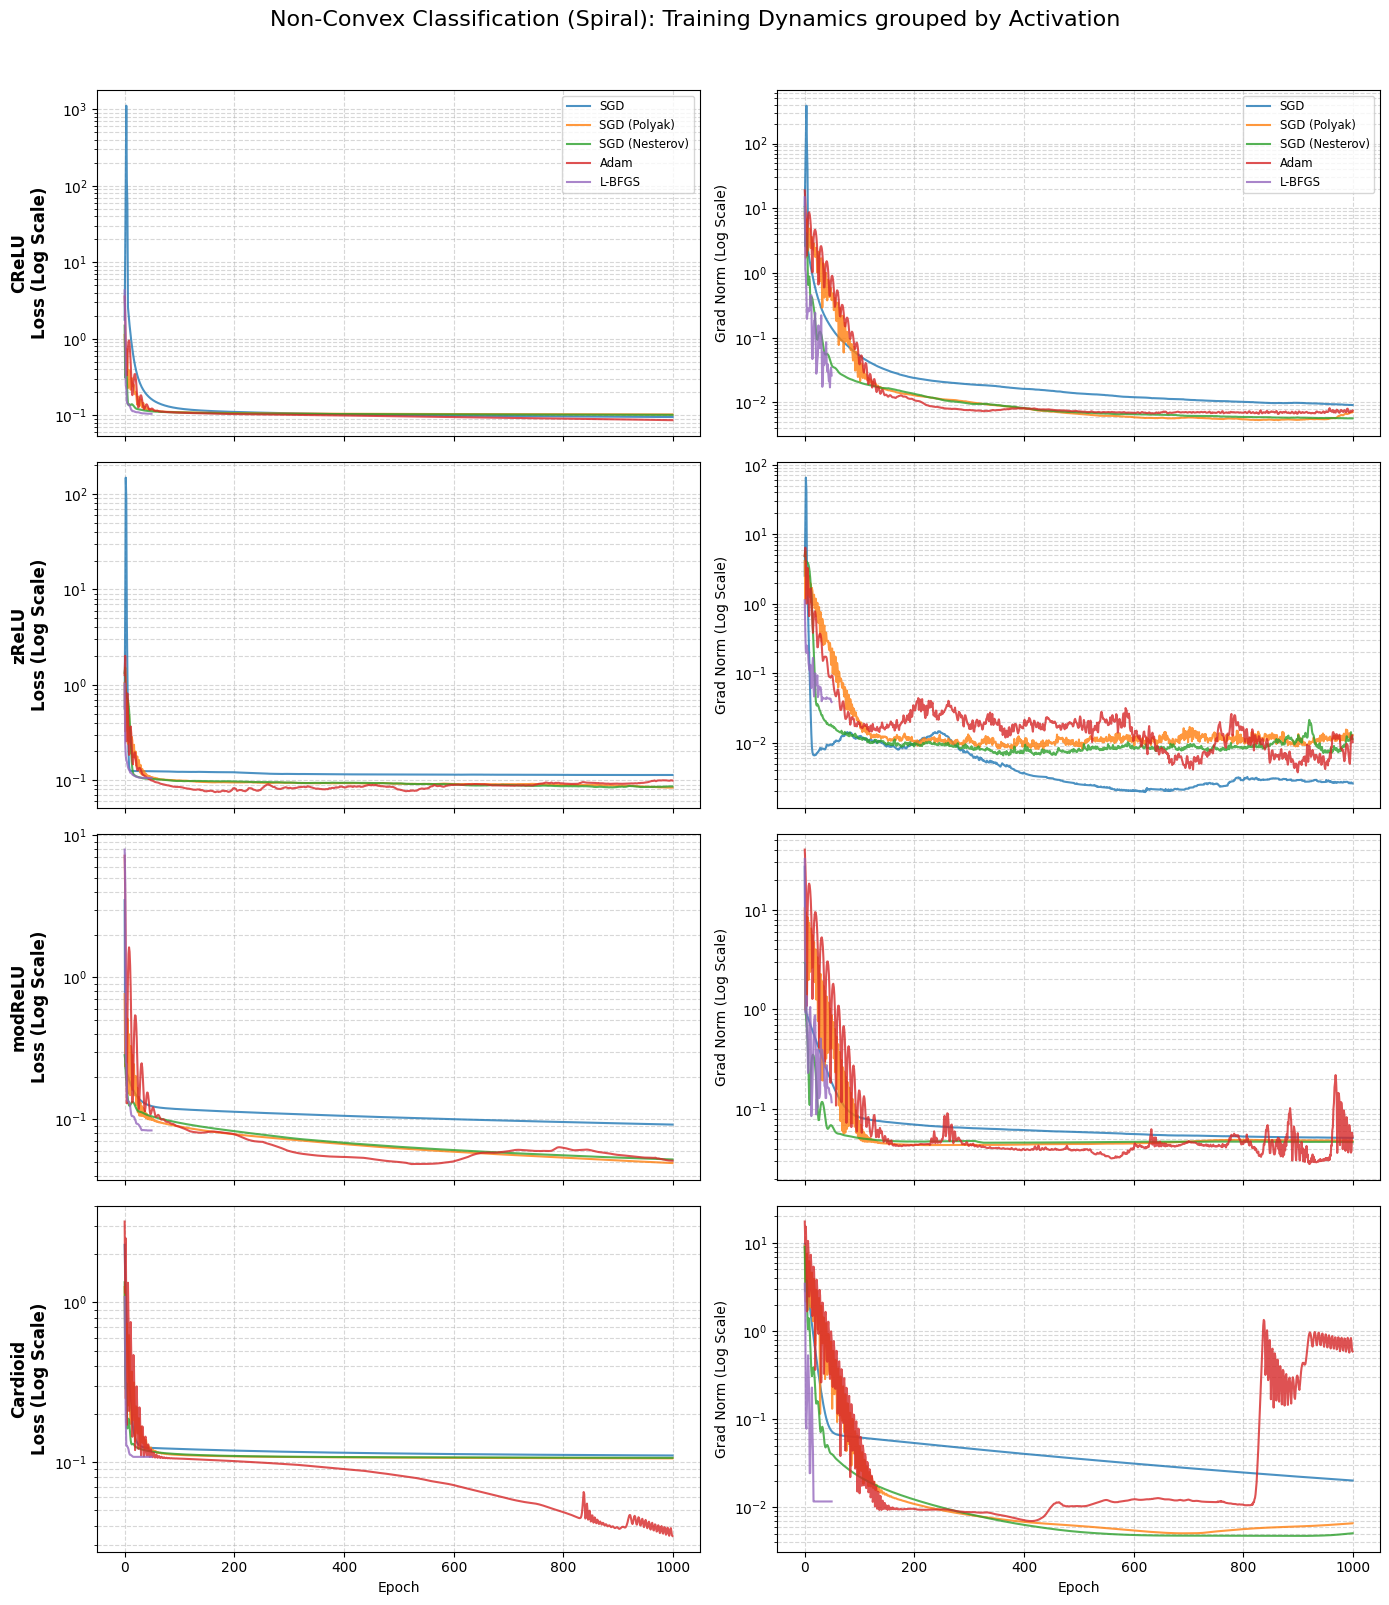


Non-Convex Classification (Spiral) Summary
Optimizer   Adam  L-BFGS   SGD  SGD (Nesterov)  SGD (Polyak)
Activation                                                  
CReLU       63.7    59.2  69.2            61.5          61.0
Cardioid    94.8    66.0  66.0            64.0          63.6
modReLU     94.4    88.6  86.2           100.0          99.1
zReLU       64.1    68.6  60.0            70.7          72.4

Running Convex Classification (Blobs)

Optimizer       | Activation | Best LR  | Acc %  | Time
-----------------------------------------------------------------
SGD             | CReLU      | 0.5      | 99.3000  | 0.18s
SGD             | zReLU      | 0.5      | 98.2000  | 0.15s
SGD             | modReLU    | 0.5      | 99.1000  | 0.24s
SGD             | Cardioid   | 0.5      | 99.1000  | 0.99s
SGD (Polyak)    | CReLU      | 0.5      | 99.3000  | 0.76s
SGD (Polyak)    | zReLU      | 1.0      | 50.0000  | 0.14s
SGD (Polyak)    | modReLU    | 0.5      | 99.3000  | 0.24s
SGD (Polyak)   

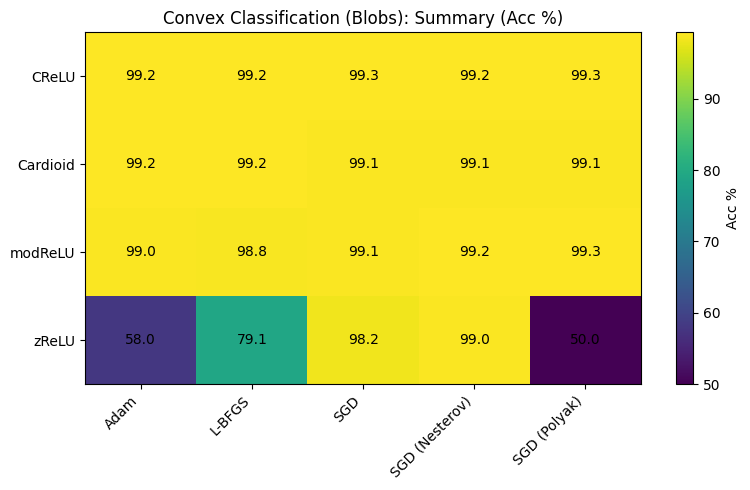

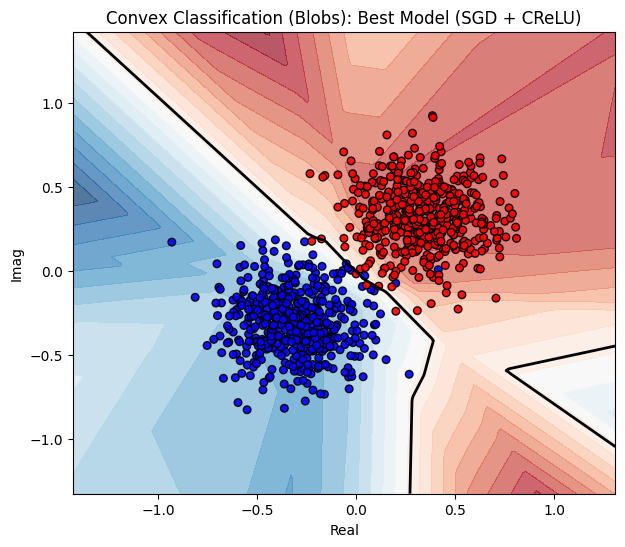

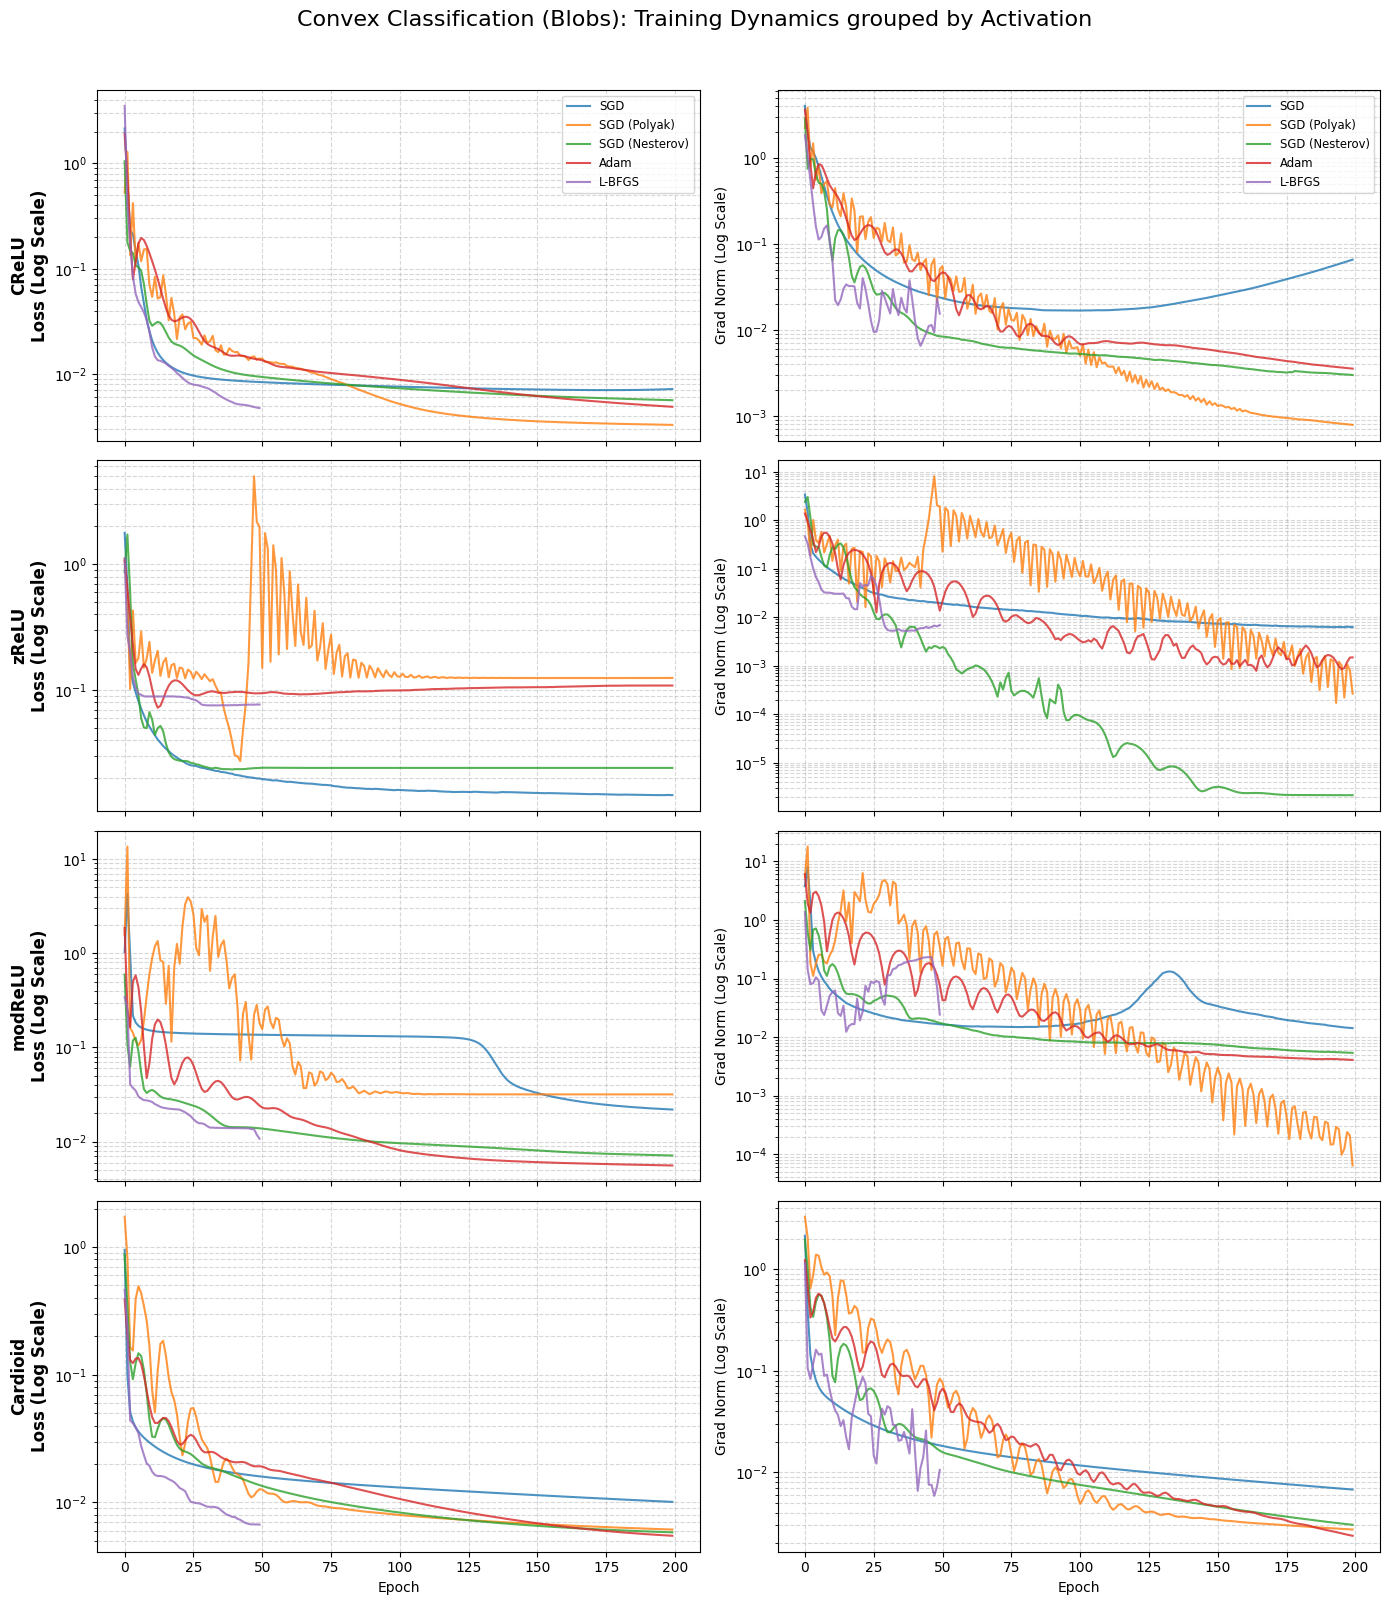


Convex Classification (Blobs) Summary
Optimizer   Adam  L-BFGS   SGD  SGD (Nesterov)  SGD (Polyak)
Activation                                                  
CReLU       99.2    99.2  99.3            99.2          99.3
Cardioid    99.2    99.2  99.1            99.1          99.1
modReLU     99.0    98.8  99.1            99.2          99.3
zReLU       58.0    79.1  98.2            99.0          50.0


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd
import warnings
import seaborn as sns

warnings.filterwarnings('ignore', category=RuntimeWarning)

### Set up classes

class Parameter:
    def __init__(self, value, requires_grad=True):
        self.data = np.array(value, dtype=np.complex128)
        self.grad = np.zeros_like(self.data, dtype=np.complex128) if requires_grad else None
        self.requires_grad = requires_grad
    def zero_grad(self):
        if self.grad is not None: self.grad.fill(0)

class Module:
    def forward(self, x): raise NotImplementedError
    def backward(self, grad_output): raise NotImplementedError
    def parameters(self): return []


### Layers with He initialization

class ComplexLinear(Module):
    def __init__(self, in_features, out_features):
        # He Initialization
        scale = np.sqrt(2.0 / in_features)
        w_init = scale * (np.random.randn(in_features, out_features) +
                          1j * np.random.randn(in_features, out_features))
        b_init = np.zeros(out_features, dtype=np.complex128)
        self.W = Parameter(w_init); self.b = Parameter(b_init)
        self.input_cache = None

    def forward(self, x):
        self.input_cache = x
        return x @ self.W.data + self.b.data

    def backward(self, grad_output):
        x = self.input_cache
        self.W.grad += np.array(x.conj().T @ grad_output)
        self.b.grad += np.array(np.sum(grad_output, axis=0))
        return grad_output @ self.W.data.conj().T

    def parameters(self): return [self.W, self.b]

### Activations

class CReLU(Module):
    def forward(self, x):
        self.mask_real = (x.real > 0); self.mask_imag = (x.imag > 0)
        return (x.real * self.mask_real) + 1j * (x.imag * self.mask_imag)
    def backward(self, grad_output):
        return (grad_output.real * self.mask_real) + 1j * (grad_output.imag * self.mask_imag)

class zReLU(Module):
    def forward(self, x):
        self.mask = (x.real > 0) & (x.imag > 0)
        return x * self.mask
    def backward(self, grad_output):
        return grad_output * self.mask

class modReLU(Module):
    def __init__(self, features, leak=0.01):
        self.b = Parameter(np.full((1, features), -0.5), requires_grad=True)
        self.leak = leak
        self.z_cache = None; self.mag_cache = None; self.mask = None

    def forward(self, z):
        self.z_cache = z
        self.mag_cache = np.abs(z) + 1e-6
        step = self.mag_cache + self.b.data.real
        self.mask = (step > 0)
        scale = np.where(self.mask, step / self.mag_cache, self.leak)
        return z * scale

    def backward(self, grad_output):
        phase = self.z_cache / self.mag_cache
        grad_input = np.where(self.mask, grad_output * self.mask, grad_output * self.leak)
        db = np.real(np.sum(grad_output * np.conj(phase) * self.mask, axis=0))
        self.b.grad += db.reshape(1, -1)
        return grad_input

    def parameters(self): return [self.b]

class ComplexCardioid(Module):
    def forward(self, z):
        self.z_cache = z; theta = np.angle(z)
        return z * 0.5 * (1 + np.cos(theta))
    def backward(self, grad_output):
        theta = np.angle(self.z_cache)
        return grad_output * 0.5 * (1 + np.cos(theta))

class Sequential(Module):
    def __init__(self, layers): self.layers = layers
    def forward(self, x):
        for l in self.layers: x = l.forward(x)
        return x
    def backward(self, grad):
        for l in reversed(self.layers): grad = l.backward(grad)
        return grad
    def parameters(self): return [p for l in self.layers for p in l.parameters()]

class PolynomialModel(Module):
    def __init__(self):
        self.w1 = Parameter(0.0 + 0.0j); self.w2 = Parameter(0.0 + 0.0j); self.b = Parameter(0.0 + 0.0j)
    def forward(self, x):
        return self.w1.data * x**2 + self.w2.data * x + self.b.data
    def backward(self, grad_output): pass
    def parameters(self): return [self.w1, self.w2, self.b]

### Optimizers

class ComplexOptimizer:
    def __init__(self, params, lr=1e-3):
        self.params = list(params); self.lr = lr; self.state = {}
    def zero_grad(self):
        for p in self.params:
            if p.grad is not None: p.grad.fill(0)

class ComplexSGD(ComplexOptimizer):
    def __init__(self, params, lr=1e-3, momentum=0.0, nesterov=False):
        super().__init__(params, lr)
        self.momentum = momentum; self.nesterov = nesterov
    def step(self, closure=None):
        loss = closure() if closure else None
        for p in self.params:
            if p.grad is None: continue
            d_p = p.grad
            if self.momentum != 0:
                buf = self.state.setdefault(id(p), {}).setdefault('momentum_buffer', np.zeros_like(p.data))
                buf[...] = (self.momentum * buf) + d_p
                if self.nesterov: d_p = d_p + self.momentum * buf
                else: d_p = buf
            p.data -= self.lr * d_p
        return loss

class ComplexAdam(ComplexOptimizer):
    def __init__(self, params, lr=1e-3):
        super().__init__(params, lr); self.betas=(0.9, 0.999); self.eps=1e-8
    def step(self, closure=None):
        loss = closure() if closure else None
        beta1, beta2 = self.betas
        for p in self.params:
            if p.grad is None: continue
            st = self.state.setdefault(id(p), {'step':0, 'm':np.zeros_like(p.data), 'v':np.zeros_like(p.data.real)})
            st['step'] += 1
            st['m'][...] = beta1 * st['m'] + (1-beta1) * p.grad
            st['v'][...] = beta2 * st['v'] + (1-beta2) * (np.abs(p.grad)**2)
            denom = (np.sqrt(st['v']) / np.sqrt(1-beta2**st['step'])) + self.eps
            p.data -= (self.lr / (1-beta1**st['step'])) * (st['m'] / denom)
        return loss

class ComplexLBFGS(ComplexOptimizer):
    def __init__(self, params, lr=1.0, history_size=10):
        super().__init__(params, lr); self.history_size=history_size
    def _dot(self, a, b): return np.real(np.vdot(a, b))
    def step(self, closure=None):
        loss = closure()
        state = self.state.setdefault('global', {'step':0, 'ro':[], 's':[], 'y':[], 'pg':None, 'pp':None})
        flat_grad = np.concatenate([p.grad.ravel() for p in self.params])
        flat_params = np.concatenate([p.data.ravel() for p in self.params])
        if state['step'] > 0:
            y = flat_grad - state['pg']; s = flat_params - state['pp']
            ys = self._dot(y, s)
            if ys > 1e-10:
                rho = 1.0/ys
                if len(state['ro']) >= self.history_size:
                    state['ro'].pop(0); state['s'].pop(0); state['y'].pop(0)
                state['ro'].append(rho); state['s'].append(s); state['y'].append(y)
        q = flat_grad.copy(); alpha = []
        for i in range(len(state['ro']) - 1, -1, -1):
            a = state['ro'][i] * self._dot(state['s'][i], q); alpha.append(a)
            q -= a * state['y'][i]
        r = q * (self._dot(state['s'][-1], state['y'][-1])/self._dot(state['y'][-1], state['y'][-1])) if state['ro'] else q
        for i in range(len(state['ro'])):
            beta = state['ro'][i] * self._dot(state['y'][i], r)
            r += state['s'][i] * (alpha[len(state['ro'])-1-i] - beta)
        d = -r; step = self.lr; gtd = self._dot(flat_grad, d)
        for _ in range(10):
            new_p = flat_params + step*d
            offset=0
            for p in self.params:
                sz = p.data.size; p.data[...] = new_p[offset:offset+sz].reshape(p.data.shape); offset+=sz
            if closure() <= loss + 1e-4*step*gtd: break
            step *= 0.5
        state['pg'] = flat_grad; state['pp'] = flat_params; state['step'] += 1
        return loss

### Plots

class Visualizer:
    @staticmethod
    def plot_convergence(results, title):
        plt.figure(figsize=(10, 4))
        for name, data in results.items(): plt.plot(data['loss'], label=name)
        plt.yscale('log'); plt.title(f"{title}: Convergence"); plt.legend(); plt.grid(True); plt.show()

    @staticmethod
    def plot_trajectory(results, title):
        plt.figure(figsize=(6, 6))
        for name, data in results.items():
            if 'w_hist' in data: plt.plot(np.array(data['w_hist']).real, np.array(data['w_hist']).imag, '.-', label=name, alpha=0.6)
        plt.scatter([0], [0], c='k', marker='x', s=100); plt.scatter([1], [1], c='r', marker='*', s=200, zorder=10)
        plt.title(f"{title}: Path (w1)"); plt.axis('equal'); plt.legend(); plt.grid(True); plt.show()

    @staticmethod
    def plot_heatmap(df, title, metric_name):
        pivot_table = df.pivot(index="Activation", columns="Optimizer", values=metric_name)
        plt.figure(figsize=(8, 5))
        plt.imshow(pivot_table, cmap='viridis', aspect='auto')
        plt.colorbar(label=metric_name)
        plt.xticks(range(len(pivot_table.columns)), pivot_table.columns, rotation=45, ha='right')
        plt.yticks(range(len(pivot_table.index)), pivot_table.index)
        for i in range(len(pivot_table.index)):
            for j in range(len(pivot_table.columns)):
                val = pivot_table.iloc[i, j]
                textcolor = "w" if val < pivot_table.values.max()/2 else "black"
                fmt = "{:.4f}" if "SER" in metric_name else "{:.1f}"
                plt.text(j, i, fmt.format(val), ha="center", va="center", color=textcolor)
        plt.title(f"{title}: Summary ({metric_name})")
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_decision_boundary(model, X, y, title, opt_name=None, act_name=None):
      # For classification experiments
        pad = 0.5
        x_min, x_max = X.real.min() - pad, X.real.max() + pad
        y_min, y_max = X.imag.min() - pad, X.imag.max() + pad
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
        z_grid = (xx + 1j * yy).reshape(-1, 1)

        out = model.forward(z_grid)
        vals = out.real.reshape(xx.shape)

        plt.figure(figsize=(7, 6))
        plt.contourf(xx, yy, vals, levels=20, cmap='RdBu_r', alpha=0.7)
        plt.contour(xx, yy, vals, levels=[0.5], colors='black', linewidths=2)
        plt.scatter(X.real, X.imag, c=y.real.ravel(), edgecolors='k', cmap='bwr', s=30, alpha=0.9)

        model_info = f" ({opt_name} + {act_name})" if opt_name and act_name else ""
        plt.title(f"{title}: Best Model{model_info}")
        plt.xlabel("Real"); plt.ylabel("Imag")
        plt.show()

    @staticmethod
    def plot_training_dynamics(results, title):
        """
        Plots Loss and Gradient Norms, grouped by Activation function
        """
        df = pd.DataFrame(results)

        groups = df['Activation'].unique()
        hue_col = 'Optimizer'
        group_label = 'Activation'

        n_groups = len(groups)
        fig, axes = plt.subplots(n_groups, 2, figsize=(14, 4 * n_groups), squeeze=False)
        fig.suptitle(f"{title}: Training Dynamics grouped by {group_label}", fontsize=16, y=1.0)

        for i, group in enumerate(groups):
            subset = df[df[group_label] == group]

            ax_loss = axes[i, 0]
            ax_grad = axes[i, 1]

            # Subplot: Loss
            for _, row in subset.iterrows():
                label = row[hue_col]
                ax_loss.plot(row['History']['loss'], label=label, alpha=0.8)
            ax_loss.set_yscale('log')
            # set row label on the left
            ax_loss.set_ylabel(f"{group}\nLoss (Log Scale)", fontsize=12, fontweight='bold')
            ax_loss.grid(True, which='both', linestyle='--', alpha=0.5)

            # only show legend on the top row to reduce clutter
            if i == 0:
                 ax_loss.legend(loc='upper right', fontsize='small')

            # only show x-label on the bottom row
            if i < n_groups - 1:
                ax_loss.set_xticklabels([])
            else:
                ax_loss.set_xlabel("Epoch")

            # Subplot: Gradient Norm
            for _, row in subset.iterrows():
                label = row[hue_col]
                ax_grad.plot(row['History']['grad_norm'], label=label, alpha=0.8)
            ax_grad.set_yscale('log')
            ax_grad.set_ylabel("Grad Norm (Log Scale)")
            ax_grad.grid(True, which='both', linestyle='--', alpha=0.5)

            # only show legend on the top row
            if i == 0:
                 ax_grad.legend(loc='upper right', fontsize='small')

            # only show x-label on the bottom row
            if i < n_groups - 1:
                ax_grad.set_xticklabels([])
            else:
                ax_grad.set_xlabel("Epoch")

        plt.tight_layout()

        plt.subplots_adjust(top=0.95 if n_groups > 1 else 0.9) # adjust top margin to make room for title
        plt.show()

### Hyperparameter Tuner

class HyperTuner:
    @staticmethod
    def get_best_config(model_fn, opt_factory_base, X, y, metric_fn, search_space, probe_epochs=50):
        best_score = float('inf'); best_factory = None; best_lr = None

        for lr in search_space:
            model = model_fn()
            opt = opt_factory_base(model.parameters(), lr=lr)
            valid_run = True
            try:
                for _ in range(probe_epochs):
                    def closure():
                        opt.zero_grad(); yp = model.forward(X); diff = yp - y
                        loss = 0.5 * np.mean(np.abs(diff)**2)
                        if np.isnan(loss) or np.isinf(loss) or loss > 1e6:
                            raise ValueError("Unstable")
                        grad = (1.0/len(y)) * diff; model.backward(grad)
                        return loss
                    opt.step(closure)
                if np.std(model.forward(X)) < 1e-6: raise ValueError("Dead Network")
                score = metric_fn(model, X, y)
                if np.isnan(score) or np.isinf(score): valid_run = False
            except (ValueError, RuntimeWarning): valid_run = False

            if valid_run and score < best_score:
                best_score = score; best_lr = lr
                def make_opt(p, _lr=lr, _fac=opt_factory_base): return _fac(p, lr=_lr)
                best_factory = make_opt

        if best_factory is None:
            def make_safe(p): return opt_factory_base(p, lr=min(search_space))
            return make_safe, min(search_space)
        return best_factory, best_lr

### Generate simulated data for experiments

def get_data(experiment, n=1000):
    np.random.seed(42)
    if experiment == 1:
        z = (np.random.rand(n)+0.5)*np.exp(1j*np.random.uniform(0, 2*np.pi, n))
        y = (1+1j)*z**2 + (-2+2j)*z + 5 + 0.1*(np.random.randn(n)+1j*np.random.randn(n))
        return z.reshape(-1,1), y.reshape(-1,1)
    elif experiment == 2:
        n2=n//2; t = np.sqrt(np.random.rand(n2))*4*np.pi
        z0 = (t+np.random.randn(n2)*0.1)*np.exp(1j*t)
        z1 = (t+np.random.randn(n2)*0.1)*np.exp(1j*(t+np.pi))
        X = np.concatenate([z0,z1]); y = np.concatenate([np.zeros(n2),np.ones(n2)])
        X /= np.max(np.abs(X)); return X.reshape(-1,1), y.reshape(-1,1)
    elif experiment == 3:
        n2 = n//2
        z0 = (-1-1j) + 0.6*(np.random.randn(n2) + 1j*np.random.randn(n2))
        z1 = (1+1j) + 0.6*(np.random.randn(n2) + 1j*np.random.randn(n2))
        X = np.concatenate([z0,z1]); y = np.concatenate([np.zeros(n2),np.ones(n2)])
        X /= np.max(np.abs(X)); return X.reshape(-1,1), y.reshape(-1,1)

### Run expeeriments

def run_experiment_1():
    print(f"Running experiment 1: Polynomial Regression\n")
    X, y = get_data(1); y = y.astype(np.complex128)
    def calc_loss(yp, yt): d=yp-yt; return 0.5*np.mean(np.abs(d)**2), (1.0/len(yt))*d

    configs = [
        ("SGD", lambda p: ComplexSGD(p, 0.1, 0.0)),
        ("SGD (Polyak)",  lambda p: ComplexSGD(p, 0.1, 0.9)),
        ("SGD (Nesterov)",lambda p: ComplexSGD(p, 0.1, 0.9, nesterov=True)),
        ("Adam",          lambda p: ComplexAdam(p, 0.05)),
        ("L-BFGS",        lambda p: ComplexLBFGS(p, 1.0))
    ]
    epochs_map = {k: 200 for k, _ in configs}; epochs_map["L-BFGS"] = 50
    results = {}

    for name, opt_fn in configs:
        model = PolynomialModel(); opt = opt_fn(model.parameters()); hist = {'loss': [], 'w_hist': []}
        for _ in range(epochs_map[name]):
            def closure():
                opt.zero_grad(); l, g = calc_loss(model.forward(X), y)
                model.w1.grad += np.sum(g * np.conj(X**2))
                model.w2.grad += np.sum(g * np.conj(X))
                model.b.grad  += np.sum(g)
                return l
            hist['loss'].append(opt.step(closure)); hist['w_hist'].append(model.w1.data.copy())
        print(f"{name:<15} | Loss: {hist['loss'][-1]:.5f}")
        results[name] = hist
    Visualizer.plot_convergence(results, "experiment 1"); Visualizer.plot_trajectory(results, "experiment 1")

def run_tuned_grid(experiment, title, model_fn_base, epochs_base, metric_name, metric_fn, viz_type="boundary"):
    print(f"\nRunning {title}\n")
    X, y = get_data(experiment); y = y.astype(np.complex128)

    activations = {"CReLU": CReLU, "zReLU": zReLU, "modReLU": lambda: modReLU(100 if experiment==2 else 10), "Cardioid": ComplexCardioid}
    opt_facts = {
        "SGD": lambda p, lr: ComplexSGD(p, lr=lr, momentum=0.0),
        "SGD (Polyak)":  lambda p, lr: ComplexSGD(p, lr=lr, momentum=0.9, nesterov=False),
        "SGD (Nesterov)":lambda p, lr: ComplexSGD(p, lr=lr, momentum=0.9, nesterov=True),
        "Adam":          lambda p, lr: ComplexAdam(p, lr=lr),
        "L-BFGS":        lambda p, lr: ComplexLBFGS(p, lr=lr)
    }
    lr_grids = {k: [1.0, 0.5, 0.1, 0.01] for k in opt_facts}
    lr_grids["Adam"] = [0.1, 0.05, 0.01, 0.005]

    results = []
    global_best_model = None
    global_best_score = -float('inf')
    global_best_opt_name = None; global_best_act_name = None

    print(f"{'Optimizer':<15} | {'Activation':<10} | {'Best LR':<8} | {metric_name:<6} | {'Time'}")
    print("-" * 65)

    for opt_name, opt_fac_base in opt_facts.items():
        for act_name, act_fac in activations.items():
            def m_fn(): return model_fn_base(act_fac)
            def tune_metric(m, x, y): return 0.5*np.mean(np.abs(m.forward(x)-y)**2)

            best_opt_fac, best_lr = HyperTuner.get_best_config(m_fn, opt_fac_base, X, y, tune_metric, lr_grids[opt_name])

            model = m_fn(); opt = best_opt_fac(model.parameters()); start = time.time()
            epochs = 50 if "L-BFGS" in opt_name else epochs_base

            # history
            hist_loss = []
            hist_grad = []

            for _ in range(epochs):
                def closure():
                    opt.zero_grad(); yp = model.forward(X); d=yp-y
                    loss = 0.5*np.mean(np.abs(d)**2); model.backward((1.0/len(y))*d); return loss

                loss_val = opt.step(closure)
                hist_loss.append(loss_val)

                # grad norm
                total_norm = 0.0
                for p in model.parameters():
                    if p.grad is not None:
                        total_norm += np.sum(np.abs(p.grad)**2)
                hist_grad.append(np.sqrt(total_norm))

            dur = time.time()-start; score = metric_fn(model, X, y)
            print(f"{opt_name:<15} | {act_name:<10} | {best_lr:<8} | {score:.4f}  | {dur:.2f}s")

            results.append({
                "Optimizer": opt_name,
                "Activation": act_name,
                metric_name: score,
                "History": {"loss": hist_loss, "grad_norm": hist_grad}
            })

            is_best = (score > global_best_score)
            if is_best:
                global_best_score = score
                global_best_model = model
                global_best_opt_name = opt_name
                global_best_act_name = act_name

    df = pd.DataFrame(results)

    Visualizer.plot_heatmap(df, title, metric_name)
    if viz_type == "boundary" and global_best_model is not None:
        Visualizer.plot_decision_boundary(global_best_model, X, y, title, global_best_opt_name, global_best_act_name)

    Visualizer.plot_training_dynamics(results, title)

    print(f"\n{title} Summary")
    print(df.pivot(index="Activation", columns="Optimizer", values=metric_name))

if __name__ == "__main__":
    run_experiment_1()

    def experiment2_model(act): return Sequential([ComplexLinear(1, 100), act(), ComplexLinear(100, 1)])
    def experiment2_metric(m, x, y): return np.mean((m.forward(x).real > 0.5) == (y.real > 0.5)) * 100
    run_tuned_grid(2, "Non-Convex Classification (Spiral)", experiment2_model, 1000, "Acc %", experiment2_metric, viz_type="boundary")

    def experiment3_model(act): return Sequential([ComplexLinear(1, 10), act(), ComplexLinear(10, 1)])
    def experiment3_metric(m, x, y): return np.mean((m.forward(x).real > 0.5) == (y.real > 0.5)) * 100
    run_tuned_grid(3, "Convex Classification (Blobs)", experiment3_model, 200, "Acc %", experiment3_metric, viz_type="boundary")